In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/raw/complaints.csv')

# Quick inspection
print(df.info())
print(df.head())

C:\Users\HP\AppData\Local\Temp\ipykernel_6996\1678354281.py:6: DtypeWarning: Columns (0: Consumer disputed?) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/complaints.csv')


<class 'pandas.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 18 columns):
 #   Column                        Dtype
---  ------                        -----
 0   Date received                 str  
 1   Product                       str  
 2   Sub-product                   str  
 3   Issue                         str  
 4   Sub-issue                     str  
 5   Consumer complaint narrative  str  
 6   Company public response       str  
 7   Company                       str  
 8   State                         str  
 9   ZIP code                      str  
 10  Tags                          str  
 11  Consumer consent provided?    str  
 12  Submitted via                 str  
 13  Date sent to company          str  
 14  Company response to consumer  str  
 15  Timely response?              str  
 16  Consumer disputed?            str  
 17  Complaint ID                  int64
dtypes: int64(1), str(17)
memory usage: 1.3 GB
None
  Date received           

In [4]:
print(df.head(5))

  Date received                                            Product  \
0    2025-06-20  Credit reporting or other personal consumer re...   
1    2025-06-20                                    Debt collection   
2    2025-06-20  Credit reporting or other personal consumer re...   
3    2025-06-20  Credit reporting or other personal consumer re...   
4    2025-06-20  Credit reporting or other personal consumer re...   

               Sub-product                                 Issue  \
0         Credit reporting  Incorrect information on your report   
1  Telecommunications debt     Attempts to collect debt not owed   
2         Credit reporting           Improper use of your report   
3         Credit reporting           Improper use of your report   
4         Credit reporting  Incorrect information on your report   

                                       Sub-issue Consumer complaint narrative  \
0            Information belongs to someone else                          NaN   
1       

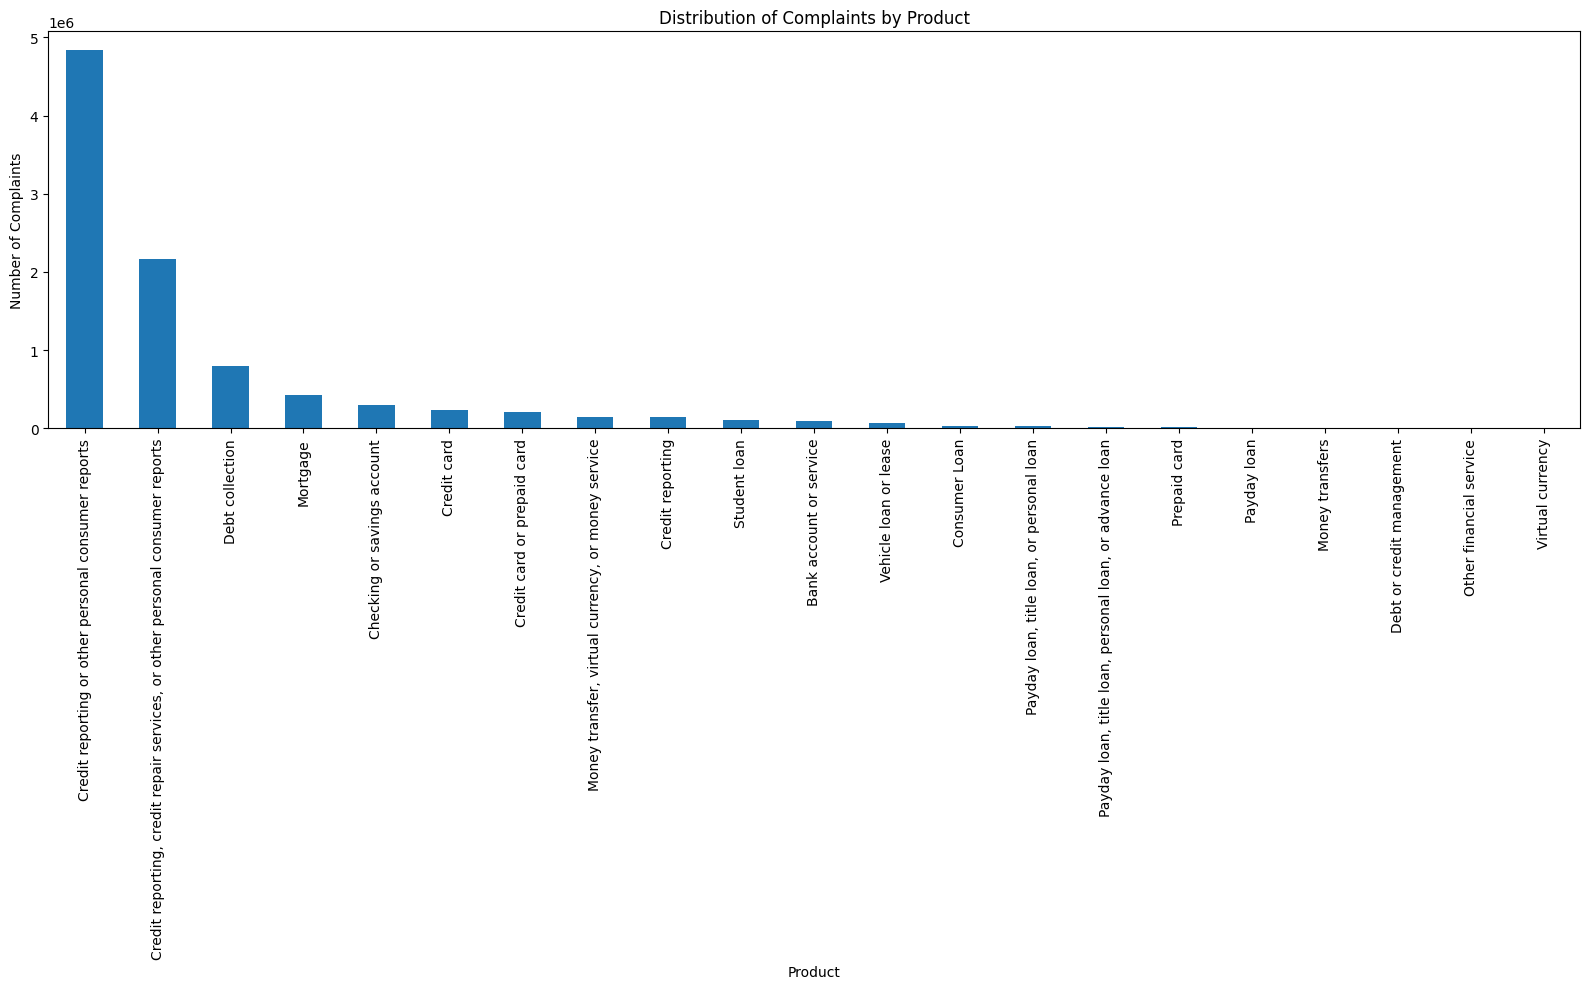

In [5]:
# 1. Distribution of complaints across products
plt.figure(figsize=(16, 10))
product_counts = df['Product'].value_counts()
product_counts.plot(kind='bar')
plt.title('Distribution of Complaints by Product')
plt.ylabel('Number of Complaints')
plt.xlabel('Product')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Key observations from the data include:

Dominant Categories: The products related to "Credit reporting or other personal consumer reports" and "Credit reporting, credit repair services, or other personal consumer reports" account for the highest volume of complaints, both exceeding 2 million, with the former approaching 5 million.

Moderate Volume: Categories such as "Debt collection," "Mortgage," "Checking or savings account," and "Credit card" represent the next tier of complaint volume, consistently showing lower numbers than the reporting categories but still significantly higher than the tail end of the distribution.

Low Volume Tail: The chart shows a long tail of financial products, including "Payday loan," "Money transfers," and "Virtual currency," which receive a negligible number of complaints in comparison to the leading categories.

Narrative Length Analysis

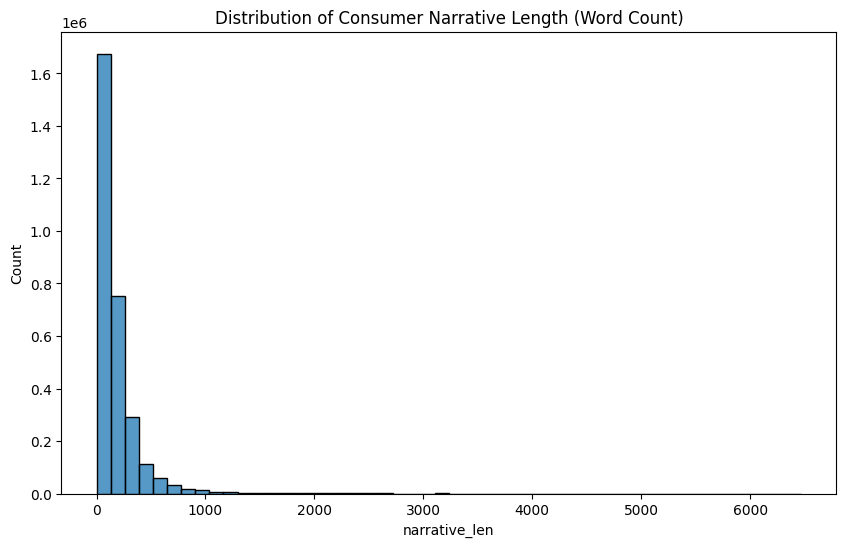

Max length: 6469
Average length: 54.46666584112027


In [ ]:
df['Consumer complaint narrative'] = df['Consumer complaint narrative'].fillna('')

# Calculate word count
df['narrative_len'] = df['Consumer complaint narrative'].apply(lambda x: len(str(x).split()))

# Visualize length
plt.figure(figsize=(10, 6))
sns.histplot(df[df['narrative_len'] > 0]['narrative_len'], bins=50)
plt.title('Distribution of Consumer Narrative Length (Word Count)')
plt.show()

# Identify outliers
print(f"Max length: {df['narrative_len'].max()}")
print(f"Average length: {df['narrative_len'].mean()}")

In [ ]:
# 2. Count complaints with and without narratives
has_narrative = df['Consumer complaint narrative'].notna() & (df['Consumer complaint narrative'] != '')

total = len(df)
with_narr = has_narrative.sum()
without_narr = total - with_narr

print(f"Total Complaints: {total}")
print(f"With Narratives: {with_narr} ({ (with_narr/total)*100:.2f}%)")
print(f"Without Narratives: {without_narr} ({ (without_narr/total)*100:.2f}%)")

Total Complaints: 9609797
With Narratives: 2980756 (31.02%)
Without Narratives: 6629041 (68.98%)


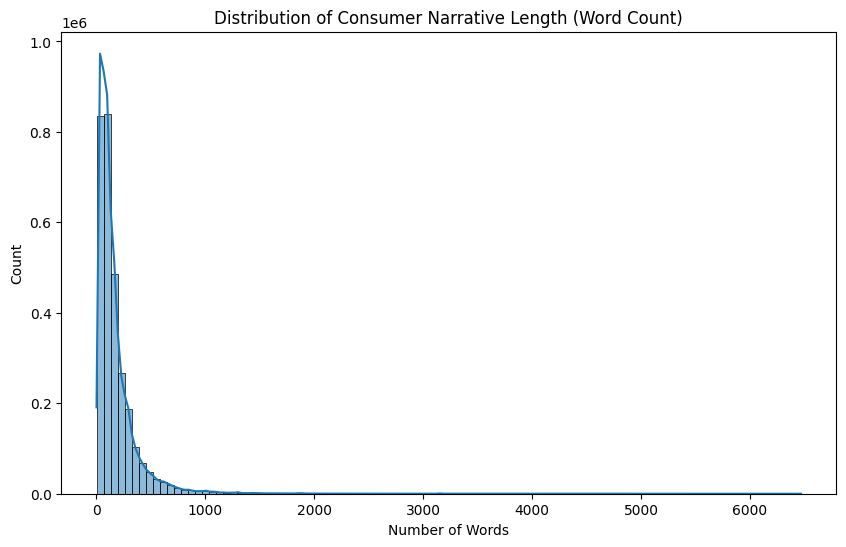

Shortest narrative: 1.0 words
Longest narrative: 6469.0 words


In [ ]:
# 3. Calculate word count
df['narrative_len'] = df.loc[has_narrative, 'Consumer complaint narrative'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(df.loc[has_narrative, 'narrative_len'], bins=100, kde=True)
plt.title('Distribution of Consumer Narrative Length (Word Count)')
plt.xlabel('Number of Words')
plt.show()

# Identify extremes
print(f"Shortest narrative: {df['narrative_len'].min()} words")
print(f"Longest narrative: {df['narrative_len'].max()} words")

In [9]:
# Check your new processed file
df_processed = pd.read_csv('../data/processed/cleaned_complaints.csv')
print(f"Number of records after processing: {len(df_processed)}")
print(df_processed[['Product', 'cleaned_narrative']].head())

Number of records after processing: 318174
                       Product  \
0                  Credit card   
1  Checking or savings account   
2                  Credit card   
3                  Credit card   
4                  Credit card   

                                   cleaned_narrative  
0  a xxxx xxxx card was opened under my name by a...  
1  i made the mistake of using my wellsfargo debi...  
2  dear cfpb, i have a secured credit card with c...  
3  i have a citi rewards cards. the credit balanc...  
4  bi am writing to dispute the following charges...  


**How do complaints fluctuate over time?**

In [ ]:
df['Date received'] = pd.to_datetime(df['Date received'], errors='coerce')
monthly_complaints = df.set_index('Date received').resample('ME').size()

plt.figure(figsize=(12, 6))
monthly_complaints.plot(kind='line', marker='o', color='royalblue')
plt.title('Monthly Complaint Volume', fontsize=15)
plt.ylabel('Number of Complaints')
plt.show()

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Index'